# Kelly Under Uncertainty: When a Small Error Becomes a Big Bet

<a href="https://www.kaggle.com/code/addarm/kelly-under-uncertainty" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

Suppose a strategy really wins 55% of even-money trades. How much capital should we risk on each trade?

Betting nothing wastes the edge. Betting everything means one loss can wipe out the account, and then there's nothing left to compound. Somewhere between those extremes is a position size that makes the best use of the edge, and the Kelly criterion is the answer to that specific optimisation problem. Kelly maximises how fast wealth compounds over many trades. That's a different target from the chance of winning the next trade (55% whatever we bet) or the expected payoff of a single trade (which would tell us to bet everything).

We'll derive Kelly from scratch, then remove the assumption that makes it work: that we know the 55%. In practice we estimate it from a sample, and a small error in that estimate becomes a large error in the bet. This is a companion to [The Mathematics of a Retail Trader's Ruin](https://www.kaggle.com/code/addarm/retail_trader_ruin), but you don't need to read it first.

## Notebook Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import brentq

pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Compounding and Log Growth

Why not just pick the bet with the best average return? Because returns compound. Start with 100, gain 50%, then lose 50%:

$$
\begin{aligned}
W_0 &= 100\\
100(1.5) &= 150\\
150(0.5) &= 75.
\end{aligned}
$$

The two returns average to zero, but wealth ends 25% lower, because the loss hits a larger balance than the gain did. In general, a win and a loss at the same fraction $f$ leave $(1+f)(1-f)=1-f^2$ of starting wealth, so the damage grows quickly with the size of the bet.

So we follow wealth itself. Let $W_n$ be wealth after $n$ trades, $f$ the fraction of current wealth risked on each trade, and $R_t$ the outcome of trade $t$: $+1$ for a win, $-1$ for a loss. Then

$$
\begin{aligned}
W_n &= W_0\prod_{t=1}^{n}(1+fR_t)\\
\log\left(\frac{W_n}{W_0}\right) &= \sum_{t=1}^{n}\log(1+fR_t).
\end{aligned}
$$

Wealth multiplies from trade to trade, and the log turns those multiplications into additions. A sum is something we know how to average.

On our even-money trade, a win multiplies wealth by $1+f$ with probability $p$, and a loss multiplies it by $1-f$ with probability $q=1-p$. The expected log growth per trade is

$$
g(f)=p\log(1+f)+q\log(1-f).
$$

If the trades are independent with the same $p$, the Law of Large Numbers says the average log growth per trade settles at $g(f)$, so wealth grows roughly like $W_0e^{n\,g(f)}$. Positive $g$ means compounding growth and negative $g$ means compounding decline. The Kelly fraction is the $f$ that maximises $g(f)$, and that's the definition we'll use throughout.

## Deriving Kelly

To find the maximum, we differentiate $g$, set the derivative to zero and solve for $f$:

$$
\begin{aligned}
g(f) &= p\log(1+f)+q\log(1-f)\\
g'(f) &= \frac{p}{1+f}-\frac{q}{1-f}\\
0 &= \frac{p}{1+f}-\frac{q}{1-f}\\
p(1-f) &= q(1+f)\\
p-pf &= q+qf\\
p-q &= f(p+q)\\
f^* &= p-q\\
&= 2p-1.
\end{aligned}
$$

The derivative measures how growth changes when we bet a little more. Where it reaches zero, extra size stops adding growth. The second derivative, $g''(f)=-p/(1+f)^2-q/(1-f)^2$, is negative everywhere, so $g$ is concave and that point is the maximum. The last two lines use $p+q=1$: the optimal fraction is the probability advantage of winning over losing. If $p\le0.5$ there's no advantage, and since we don't take the other side of the trade we write $f_{\mathrm{Kelly}}=\max(0,\,2p-1)$.

For our strategy:

$$
\begin{aligned}
p &= 0.55\\
f^* &= 2p-1\\
&= 2(0.55)-1\\
&= 0.10.
\end{aligned}
$$

If $p$ really is 55%, full Kelly says risk 10% of current wealth on each trade. The formula $2p-1$ belongs to the even-money case. For a bet that pays $b$ per unit risked, the same steps give $f^*=p-q/b$.

## The Growth Curve

The shape of $g$ around its peak decides what a wrong bet costs. With the true $p=0.55$,

$$
g(f)=0.55\log(1+f)+0.45\log(1-f).
$$

At $f=0$ there's no growth. Increasing $f$ makes better use of the edge, and growth peaks at $f=10\%$. Beyond Kelly, bigger bets make growth worse, and at about $f=19.9\%$ expected log growth is back to zero. Past that point the trade still has positive arithmetic expectancy, $\mathbb E[fR]=f(p-q)$, which is $+0.02$ at $f=0.20$. Its compound growth is negative all the same. A trade can make money on average and still shrink your account if you bet too much of it.

A quadratic approximation shows why, as intuition only (the exact result is the derivation above). Using $\log(1+x)\approx x-\tfrac12x^2$,

$$
\begin{aligned}
g(f) &\approx p\left(f-\tfrac12f^2\right)+q\left(-f-\tfrac12f^2\right)\\
&= f(p-q)-\tfrac12f^2\\
g(f)\approx0 &\Rightarrow f\approx2(p-q)=0.20.
\end{aligned}
$$

The first term rewards using the edge and grows in proportion to $f$. The second is the cost of compounding a volatile outcome, and it grows with $f^2$, so it catches up with the reward at about twice Kelly. Near the peak the curve is roughly symmetric: betting 5% or 15% each keeps about three quarters of the best growth rate.

Kelly fraction: 0.10, peak growth: 0.005008, zero-growth fraction: 0.1987
       f       g_f  share_of_peak  quadratic_approx
0.000000  0.000000       0.000000          0.000000
0.050000  0.003753       0.749268          0.003750
0.100000  0.005008       1.000000          0.005000
0.150000  0.003736       0.745862          0.003750
0.200000 -0.000138      -0.027502          0.000000
0.300000 -0.016203      -3.235262         -0.015000


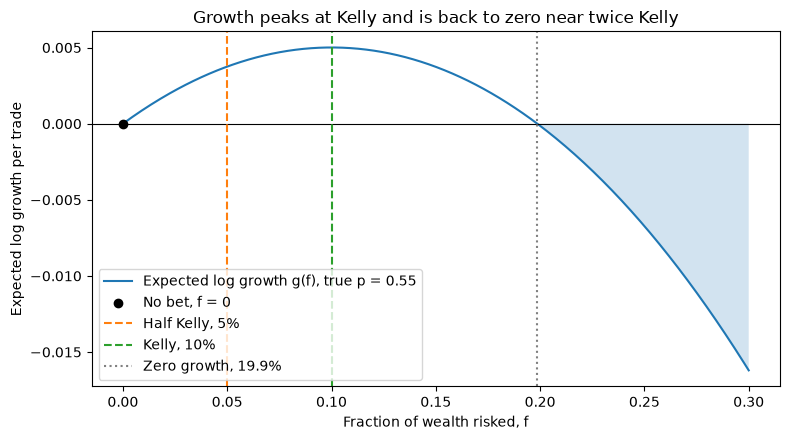

In [2]:
def kelly_fraction(p_hat):
    return np.maximum(0, 2 * p_hat - 1)


def expected_log_growth(f, p=0.55):
    return p * np.log1p(f) + (1 - p) * np.log1p(-f)


true_p = 0.55
true_kelly = kelly_fraction(true_p)
zero_growth = brentq(expected_log_growth, true_kelly, 0.9)
peak_growth = expected_log_growth(true_kelly)

growth_check = pd.DataFrame({"f": [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]})
growth_check["g_f"] = expected_log_growth(growth_check["f"])
growth_check["share_of_peak"] = growth_check["g_f"] / peak_growth
growth_check["quadratic_approx"] = growth_check["f"] * (2 * true_p - 1) - 0.5 * growth_check["f"] ** 2
print(f"Kelly fraction: {true_kelly:.2f}, peak growth: {peak_growth:.6f}, zero-growth fraction: {zero_growth:.4f}")
print(growth_check.to_string(index=False))

f_grid = np.linspace(0, 0.30, 400)
g_grid = expected_log_growth(f_grid)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f_grid, g_grid, label="Expected log growth g(f), true p = 0.55")
ax.fill_between(f_grid, g_grid, 0, where=g_grid < 0, alpha=0.2)
ax.axhline(0, color="black", linewidth=0.8)
ax.scatter([0], [0], color="black", zorder=3, label="No bet, f = 0")
ax.axvline(0.5 * true_kelly, linestyle="--", color="C1", label="Half Kelly, 5%")
ax.axvline(true_kelly, linestyle="--", color="C2", label="Kelly, 10%")
ax.axvline(zero_growth, linestyle=":", color="grey", label=f"Zero growth, {zero_growth:.1%}")
ax.set_xlabel("Fraction of wealth risked, f")
ax.set_ylabel("Expected log growth per trade")
ax.set_title("Growth peaks at Kelly and is back to zero near twice Kelly")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## One Uncomfortable Assumption

The mathematics above contains one uncomfortable assumption: we knew $p$.

In real trading nobody hands us $p$. We estimate it from the trades we've seen. Suppose our record is

$$
\begin{aligned}
n &= 100\\
K &= 55\\
\hat p &= \frac{55}{100}=0.55,
\end{aligned}
$$

where $n$ is the number of trades, $K$ the number of wins and $\hat p$ our estimate of $p$. Fifty-five wins doesn't mean the true probability is exactly 55%. Another 100 trades from the same strategy could easily produce 50 wins, or 60.

What we need is a range of values of $p$ that are reasonably consistent with 55 wins in 100. The Wilson interval (Wilson, 1927) gives one. Assuming independent trades, with $z\approx1.96$ for 95% confidence, its lower and upper ends $L$ and $U$ are

$$
\begin{aligned}
c &= \frac{\hat p+\dfrac{z^2}{2n}}{1+\dfrac{z^2}{n}}\\
h &= \frac{z}{1+\dfrac{z^2}{n}}\sqrt{\frac{\hat p(1-\hat p)}{n}+\frac{z^2}{4n^2}}\\
L &= c-h\\
U &= c+h.
\end{aligned}
$$

For our sample the 95% interval is $p\in[0.452,\,0.644]$. The data are consistent with a slightly losing strategy and with a very good one. So what does that range do to the bet?

In [3]:
def wilson_interval(successes, trials, z=1.959963984540054):
    estimate = successes / trials
    denominator = 1 + z**2 / trials
    center = (estimate + z**2 / (2 * trials)) / denominator
    half_width = z / denominator * np.sqrt(estimate * (1 - estimate) / trials + z**2 / (4 * trials**2))
    return center - half_width, center + half_width


wilson_lower, wilson_upper = wilson_interval(55, 100)
sizing = pd.DataFrame({"p_hat": [wilson_lower, 0.50, 0.55, 0.60, wilson_upper]})
sizing["kelly_fraction"] = kelly_fraction(sizing["p_hat"])
sizing["vs_true_kelly"] = sizing["kelly_fraction"] / true_kelly
print(f"Wilson 95% interval for 55/100: [{wilson_lower:.3f}, {wilson_upper:.3f}]")
print(sizing.to_string(index=False))

Wilson 95% interval for 55/100: [0.452, 0.644]
   p_hat  kelly_fraction  vs_true_kelly
0.452446        0.000000       0.000000
0.500000        0.000000       0.000000
0.550000        0.100000       1.000000
0.600000        0.200000       2.000000
0.643855        0.287709       2.877092


## From Estimation Error to Sizing Error

Plug-in Kelly treats the estimate as if it were the truth:

$$
\begin{aligned}
\hat f &= \max(0,\,2\hat p-1)\\[4pt]
\hat p=0.50 &\Rightarrow \hat f=0\%\\
\hat p=0.55 &\Rightarrow \hat f=10\%\\
\hat p=0.60 &\Rightarrow \hat f=20\%.
\end{aligned}
$$

A five-percentage-point error in $p$ sounds small. But Kelly sizes the edge above 50% rather than the win probability itself, because $2p-1=2(p-0.5)$. At $p=0.55$ the edge is five percentage points. At $\hat p=0.60$ the estimated edge is ten percentage points. The edge has doubled, so the Kelly position doubles from 10% to 20%.

A five-percentage-point estimation error in $p$ has produced a 100% error in position size.

Across the whole Wilson interval, the Kelly fraction runs from 0% to about 29%. Now put the 0.60 estimate next to the growth curve:

$$
\begin{aligned}
\hat p &= 0.60\\
\hat f_{\text{Kelly}} &= 20\%\\
f_{\text{zero growth}} &\approx 19.9\%.
\end{aligned}
$$

The true win rate is 55%, but our 100-trade sample makes it look like 60%. Plug-in Kelly tells us to bet about 20%, which is roughly the size at which true compound growth has already fallen back to zero. We'd be running a strategy with a real edge and getting nothing from it. The two directions of error don't cost the same, either. A pessimistic estimate can at worst set the size to zero and earn nothing. An optimistic one has no such floor: an estimate of 0.65 puts us at 30%, losing about three times the best possible growth rate on every trade.

## How Often Does This Happen?

If the trades are independent and the true win rate is 0.55, the number of wins in 100 trades follows a Binomial distribution:

$$
K\sim\operatorname{Binomial}(100,\,0.55),\qquad \hat p=\frac{K}{100}.
$$

Each possible sample gives one $K$, one estimate and one Kelly size. Two events matter: $K\le50$, where Kelly says don't trade, and $K\ge60$, where Kelly says bet at least 20%. Both probabilities can be computed exactly.

In [4]:
n_trades = 100
wins_dist = stats.binom(n_trades, true_p)
p_no_trade = wins_dist.cdf(50)
p_overbet = wins_dist.sf(59)
print(f"P(p_hat <= 0.50) = P(K <= 50) = {p_no_trade:.4f}")
print(f"P(p_hat >= 0.60) = P(K >= 60) = {p_overbet:.4f}")
print(f"Kelly size at p_hat = 0.60: {kelly_fraction(0.60):.2f}, zero-growth boundary: {zero_growth:.3f}")

P(p_hat <= 0.50) = P(K <= 50) = 0.1827
P(p_hat >= 0.60) = P(K >= 60) = 0.1831
Kelly size at p_hat = 0.60: 0.20, zero-growth boundary: 0.199


Both come out at about 18%. Sampling noise alone tells roughly one trader in five not to trade at all, and tells another, watching the same underlying strategy, to bet around 20%. The strategy hasn't changed. Only the sample has.

The two mistakes aren't equally costly. The first trader gives up growth. The second runs a real edge at zero or negative compound growth.

## Fractional Kelly

If the estimate can be wrong, the natural response is to bet less than it suggests. Fractional Kelly scales the Kelly size by a fixed factor $\lambda$, and half Kelly is the case $\lambda=0.5$:

$$
\begin{aligned}
f_\lambda &= \lambda f_{\text{Kelly}}, \qquad 0<\lambda<1\\
f_{\text{half}} &= 0.5f_{\text{Kelly}}.
\end{aligned}
$$

Take the same mistaken estimate:

$$
\begin{aligned}
\hat p &= 0.60\\
f_{\text{full}} &= 20\%\\
f_{\text{half}} &= 10\%.
\end{aligned}
$$

In this example, the estimation error that pushes full Kelly to about the zero-growth boundary pushes half Kelly to 10%, which is the true full-Kelly optimum. That's a coincidence of these particular numbers, not a general property of half Kelly.

More generally, fractional Kelly is a trade. It gives up some growth when the estimate is right: at 5%, half Kelly keeps about three quarters of the peak growth rate. In exchange, its size is less sensitive when the estimate is wrong. Because the growth curve is concave and the cost of a bigger bet grows with $f^2$, modest underbetting costs much less than severe overbetting. Half Kelly isn't optimal in general, and $\lambda=0.5$ isn't special; MacLean, Thorp and Ziemba (2010) study the trade-off in detail. The figure below puts the whole argument on one curve.

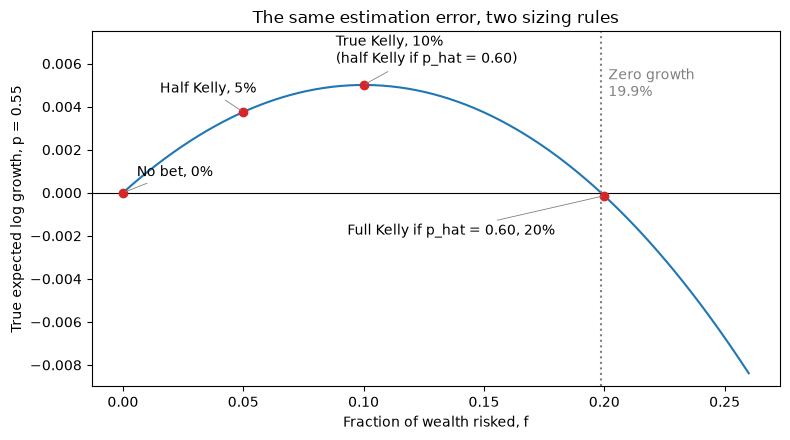

In [5]:
summary_grid = np.linspace(0, 0.26, 300)
marks = [
    (0.0, "No bet, 0%", (10, 12)),
    (0.5 * true_kelly, "Half Kelly, 5%", (-60, 14)),
    (true_kelly, "True Kelly, 10%\n(half Kelly if p_hat = 0.60)", (-20, 16)),
    (kelly_fraction(0.60), "Full Kelly if p_hat = 0.60, 20%", (-185, -28)),
]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(summary_grid, expected_log_growth(summary_grid), color="C0")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(zero_growth, linestyle=":", color="grey")
ax.text(zero_growth + 0.003, 0.0045, f"Zero growth\n{zero_growth:.1%}", color="grey")
for size, label, offset in marks:
    ax.scatter([size], [expected_log_growth(size)], color="C3", zorder=3)
    ax.annotate(label, (size, expected_log_growth(size)), textcoords="offset points", xytext=offset, arrowprops={"arrowstyle": "-", "color": "grey", "linewidth": 0.6})
ax.set_xlabel("Fraction of wealth risked, f")
ax.set_ylabel("True expected log growth, p = 0.55")
ax.set_title("The same estimation error, two sizing rules")
ax.set_ylim(-0.009, 0.0075)
plt.tight_layout()
plt.show()

Not betting earns nothing. Half Kelly from a correct estimate sits a little below the peak, and true Kelly sits on it. An estimate of 0.60 sends full Kelly to 20%, just past the dotted zero-growth line, while half Kelly from the same estimate lands back on the peak.

## A Quick Simulation

The argument above is exact, so the simulation is only a check that repeated sampling behaves as the Binomial calculation says. We draw 10,000 histories of 100 trades with true $p=0.55$, count the wins in each, size the bet with full and half Kelly from that count, and score each size on the true growth curve.

                 quantity  simulated    exact
               P(K >= 60)   0.183000 0.183057
               P(K <= 50)   0.176300 0.182728
  mean growth, full Kelly   0.001137 0.001132
  mean growth, half Kelly   0.003032 0.003018
P(growth < 0), full Kelly   0.183000 0.183057
P(growth < 0), half Kelly   0.001400 0.001536
Exact mean growth as a share of the peak: full Kelly 23%, half Kelly 60%


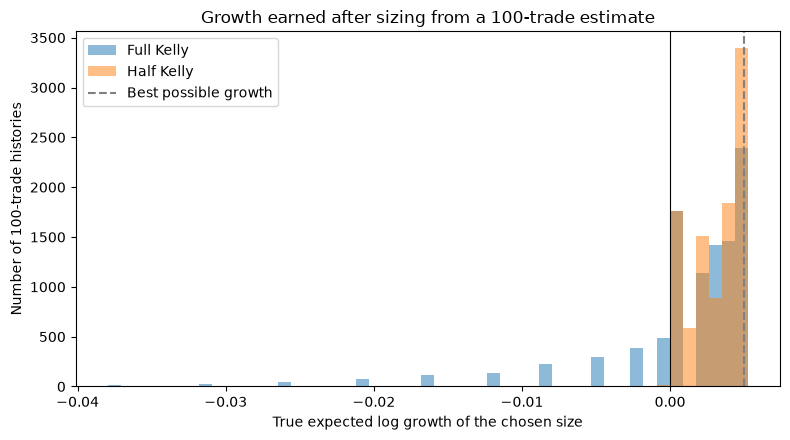

In [6]:
k_values = np.arange(n_trades + 1)
k_probs = wins_dist.pmf(k_values)
full_by_k = expected_log_growth(np.minimum(kelly_fraction(k_values / n_trades), 0.999))
half_by_k = expected_log_growth(0.5 * kelly_fraction(k_values / n_trades))

sim_rng = np.random.default_rng(42)
n_histories = 10_000
sim_wins = (sim_rng.random((n_histories, n_trades)) < true_p).sum(axis=1)
sim_full, sim_half = full_by_k[sim_wins], half_by_k[sim_wins]

check = pd.DataFrame(
    {
        "quantity": ["P(K >= 60)", "P(K <= 50)", "mean growth, full Kelly", "mean growth, half Kelly", "P(growth < 0), full Kelly", "P(growth < 0), half Kelly"],
        "simulated": [(sim_wins >= 60).mean(), (sim_wins <= 50).mean(), sim_full.mean(), sim_half.mean(), (sim_full < 0).mean(), (sim_half < 0).mean()],
        "exact": [p_overbet, p_no_trade, (k_probs * full_by_k).sum(), (k_probs * half_by_k).sum(), k_probs[full_by_k < 0].sum(), k_probs[half_by_k < 0].sum()],
    }
)
print(check.to_string(index=False))
print(f"Exact mean growth as a share of the peak: full Kelly {(k_probs * full_by_k).sum() / peak_growth:.0%}, half Kelly {(k_probs * half_by_k).sum() / peak_growth:.0%}")

growth_bins = np.linspace(np.quantile(sim_full, 0.002), peak_growth * 1.05, 50)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sim_full, bins=growth_bins, alpha=0.5, label="Full Kelly")
ax.hist(sim_half, bins=growth_bins, alpha=0.5, label="Half Kelly")
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(peak_growth, linestyle="--", color="grey", label="Best possible growth")
ax.set_xlabel("True expected log growth of the chosen size")
ax.set_ylabel("Number of 100-trade histories")
ax.set_title("Growth earned after sizing from a 100-trade estimate")
ax.legend()
plt.tight_layout()
plt.show()

The simulated frequencies and average growth rates match the exact values within sampling error. Averaged over every possible sample, full Kelly sized from the estimate earns only about 23% of the best possible growth rate and ends up with negative growth about 18% of the time. Half Kelly earns about 60% and goes negative about 0.15% of the time. The histogram shows why: full Kelly has a long left tail of overbets and half Kelly has almost none. The tall bar at zero is the samples where neither rule traded.

# Conclusion

Kelly isn't reckless. Under its assumptions, it's the position size that maximises long-run expected log growth. The practical problem is that Kelly needs the edge as an input, and in trading that edge is estimated rather than known, so estimation error becomes position-sizing error. When the true edge is small, a modest error in the estimated win probability becomes a large relative error in the Kelly fraction, and overbetting is the expensive direction. Fractional Kelly gives up some theoretical growth to make sizing less sensitive to that uncertainty.

$$
\boxed{\text{Edge}\rightarrow\text{Compounding}\rightarrow\text{Kelly}\rightarrow\text{Unknown }p\rightarrow\text{Wilson uncertainty}\rightarrow\text{Sizing error}\rightarrow\text{Overbetting}\rightarrow\text{Fractional Kelly}}
$$

For the broader picture, [The Mathematics of a Retail Trader's Ruin](https://www.kaggle.com/code/addarm/retail_trader_ruin) covers expectancy, compounding, gambler's ruin, Markov chains and the selection bias behind backtested strategies.

## References

1. Kelly, J. L., Jr. (1956). *A New Interpretation of Information Rate*. https://doi.org/10.1002/j.1538-7305.1956.tb03809.x

2. Wilson, E. B. (1927). *Probable Inference, the Law of Succession, and Statistical Inference*. https://doi.org/10.1080/01621459.1927.10502953

3. Thorp, E. O. (2006). *The Kelly Criterion in Blackjack, Sports Betting, and the Stock Market*. https://doi.org/10.1016/S1872-0978(06)01009-X

4. MacLean, L. C., Thorp, E. O., and Ziemba, W. T. (2010). *Long-Term Capital Growth: The Good and Bad Properties of the Kelly and Fractional Kelly Capital Growth Criteria*. https://doi.org/10.1080/14697688.2010.506108

# GitHub

This article is also available on [GitHub](https://github.com/adamd1985/quant_research/blob/main/kelly_under_uncertainty.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/kelly-under-uncertainty)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

# CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.